# Stage 6 Classifier Results Inspection

This notebook loads classifier validation outputs and gives quick sanity checks plus visual comparisons.

It expects artifacts produced by `scripts/03_run_classifiers.py` under:
- `results/classifier/<method>/scores.parquet`
- `results/classifier/<method>/meta.json`

In [9]:
from pathlib import Path
import json
import sys

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 180)


def resolve_repo_root() -> Path:
    cwd = Path.cwd().resolve()
    if (cwd / "results").exists() and (cwd / "scripts").exists():
        return cwd
    if cwd.name == "notebooks" and (cwd.parent / "results").exists() and (cwd.parent / "scripts").exists():
        return cwd.parent
    raise FileNotFoundError(
        "Could not resolve repository root from current working directory. "
        "Open the notebook in the project workspace root or notebooks folder."
    )


REPO_ROOT = resolve_repo_root()
CLASSIFIER_RESULTS_DIR = REPO_ROOT / "results" / "classifier"
SPLITS_META_PATH = REPO_ROOT / "data" / "processed" / "splits_meta.json"

if str(REPO_ROOT) not in sys.path:
    sys.path.append(str(REPO_ROOT))
from src.statistics import nadeau_bengio_se

splits_meta = json.loads(SPLITS_META_PATH.read_text(encoding="utf-8"))
TEST_SIZE = float(splits_meta["test_size"])
N_SAMPLES = int(splits_meta["n_samples"])
N_TEST = int(round(TEST_SIZE * N_SAMPLES))
N_TRAIN = N_SAMPLES - N_TEST

print(f"Repo root: {REPO_ROOT}")
print(f"Classifier results dir: {CLASSIFIER_RESULTS_DIR}")
print(
    f"Nadeau-Bengio: n_samples={N_SAMPLES} test_size={TEST_SIZE:.4f} "
    f"-> n_train={N_TRAIN} n_test={N_TEST} (ratio={N_TEST / N_TRAIN:.4f})"
)

Repo root: C:\Programmering\exjobb\MSc26_Proteomics
Classifier results dir: C:\Programmering\exjobb\MSc26_Proteomics\results\classifier
Nadeau-Bengio: n_samples=512 test_size=0.2000 -> n_train=410 n_test=102 (ratio=0.2488)


## Load Scores And Metadata

This cell discovers all methods with `scores.parquet` and combines them into one dataframe for comparison.

In [10]:
def load_classifier_results(base_dir: Path) -> tuple[pd.DataFrame, dict[str, dict]]:
    if not base_dir.exists():
        raise FileNotFoundError(f"Classifier results directory not found: {base_dir}")

    frames: list[pd.DataFrame] = []
    meta_by_method: dict[str, dict] = {}

    for method_dir in sorted(base_dir.iterdir()):
        if not method_dir.is_dir():
            continue

        scores_path = method_dir / "scores.parquet"
        meta_path = method_dir / "meta.json"
        if not scores_path.exists():
            continue

        method_name = method_dir.name
        df = pd.read_parquet(scores_path).copy()
        df["method"] = method_name
        df["k"] = df["k"].astype(str)
        frames.append(df)

        if meta_path.exists():
            meta_by_method[method_name] = json.loads(meta_path.read_text(encoding="utf-8"))

    if not frames:
        raise FileNotFoundError(
            f"No scores.parquet files found under: {base_dir}"
        )

    all_scores = pd.concat(frames, ignore_index=True)
    return all_scores, meta_by_method


scores, meta_by_method = load_classifier_results(CLASSIFIER_RESULTS_DIR)

print(f"Methods loaded: {sorted(scores['method'].unique().tolist())}")
print(f"Total rows: {len(scores):,}")
print(f"Columns: {scores.columns.tolist()}")

display(scores.head())

Methods loaded: ['random', 'ttest']
Total rows: 1,500
Columns: ['split_id', 'classifier', 'k', 'auc', 'aupr', 'n_features_actual', 'method']


,split_id,classifier,k,auc,aupr,n_features_actual,method
0,0,LogisticRegression,10,0.550000,0.354715,10,random
1,0,RandomForest,10,0.492424,0.154514,10,random
2,0,XGBoost,10,0.621212,0.189341,10,random
3,0,LogisticRegression,25,0.534848,0.308520,25,random
4,0,RandomForest,25,0.550000,0.198102,25,random


In [11]:
required_cols = {"split_id", "classifier", "k", "auc", "aupr", "n_features_actual", "method"}
missing_cols = required_cols.difference(scores.columns)
if missing_cols:
    raise ValueError(f"Missing expected columns: {sorted(missing_cols)}")

coverage = (
    scores.groupby("method", as_index=False)
    .agg(
        n_rows=("split_id", "size"),
        n_splits=("split_id", "nunique"),
        n_classifiers=("classifier", "nunique"),
        nan_auc=("auc", lambda s: int(s.isna().sum())),
        nan_aupr=("aupr", lambda s: int(s.isna().sum())),
    )
)

k_values_by_method = (
    scores.groupby("method")["k"]
    .apply(lambda s: sorted(s.unique().tolist()))
    .rename("k_values")
    .reset_index()
)

coverage = coverage.merge(k_values_by_method, on="method", how="left")

print("Coverage by method")
display(coverage)

if meta_by_method:
    print("Loaded metadata keys:")
    for method, meta in sorted(meta_by_method.items()):
        print(f"- {method}: {sorted(meta.keys())}")

Coverage by method


,method,n_rows,n_splits,n_classifiers,nan_auc,nan_aupr,k_values
0,random,750,50,3,0,0,"[10, 100, 25, 50, native]"
1,ttest,750,50,3,6,6,"[10, 100, 25, 50, native]"


Loaded metadata keys:
- random: ['cohort_path', 'failed_fits', 'includes_native', 'method', 'n_rows', 'n_splits', 'runtime_seconds', 'scores_path', 'seed', 'selections_path', 'split_seed_rule', 'splits_path', 'topk_values']
- ttest: ['cohort_path', 'failed_fits', 'includes_native', 'method', 'n_rows', 'n_splits', 'runtime_seconds', 'scores_path', 'seed', 'selections_path', 'split_seed_rule', 'splits_path', 'topk_values']


## Aggregate Performance Table

`auc_se_nb` / `aupr_se_nb` are Nadeau–Bengio corrected standard errors of the mean across the random 80/20 splits, accounting for shared test patients across folds. `auc_sd_split` / `aupr_sd_split` show the raw split-to-split spread (i.e. variability of the per-split metric, not population SE).

In [12]:
k_order = [str(k) for k in [10, 25, 50, 100]] + ["native"]
scores["k"] = pd.Categorical(scores["k"], categories=k_order, ordered=True)

summary = (
    scores.groupby(["method", "classifier", "k"], observed=True, as_index=False)
    .agg(
        n_rows=("split_id", "size"),
        n_splits=("split_id", "nunique"),
        auc_mean=("auc", "mean"),
        auc_sd_split=("auc", "std"),
        aupr_mean=("aupr", "mean"),
        aupr_sd_split=("aupr", "std"),
        n_features_mean=("n_features_actual", "mean"),
        n_features_min=("n_features_actual", "min"),
        n_features_max=("n_features_actual", "max"),
    )
)

summary["auc_se_nb"] = summary.apply(
    lambda r: nadeau_bengio_se(r["auc_sd_split"], int(r["n_splits"]), N_TRAIN, N_TEST),
    axis=1,
)
summary["aupr_se_nb"] = summary.apply(
    lambda r: nadeau_bengio_se(r["aupr_sd_split"], int(r["n_splits"]), N_TRAIN, N_TEST),
    axis=1,
)

summary = summary.sort_values(["classifier", "k", "method"]).reset_index(drop=True)

display(summary)

leaderboard = summary.sort_values(["auc_mean", "aupr_mean"], ascending=False).head(20)
print("Top 20 method/classifier/k combinations by mean AUC then mean AUPR")
display(leaderboard)

,method,classifier,k,n_rows,n_splits,auc_mean,auc_sd_split,aupr_mean,aupr_sd_split,n_features_mean,n_features_min,n_features_max,auc_se_nb,aupr_se_nb
0,random,LogisticRegression,10,50,50,0.516848,0.078990,0.184407,0.055276,10.0,10,10,0.040952,0.028657
1,ttest,LogisticRegression,10,50,50,0.566727,0.066999,0.208347,0.056938,10.0,10,10,0.034735,0.029519
2,random,LogisticRegression,25,50,50,0.548879,0.075951,0.204519,0.056555,25.0,25,25,0.039376,0.029321
3,ttest,LogisticRegression,25,50,50,0.592303,0.078927,0.222970,0.062767,25.0,25,25,0.040919,0.032541
4,random,LogisticRegression,50,50,50,0.593364,0.059958,0.219885,0.049467,50.0,50,50,0.031085,0.025646
5,ttest,LogisticRegression,50,50,50,0.612667,0.066905,0.239772,0.062530,50.0,50,50,0.034686,0.032418
6,random,LogisticRegression,100,50,50,0.602061,0.070614,0.229101,0.066420,100.0,100,100,0.036609,0.034435
7,ttest,LogisticRegression,100,50,50,0.637682,0.064440,0.254348,0.064466,100.0,100,100,0.033408,0.033422
8,random,LogisticRegression,native,50,50,0.541758,0.074699,0.202748,0.059188,20.0,20,20,0.038727,0.030685
9,ttest,LogisticRegression,native,50,50,0.559438,0.053726,0.194494,0.038368,11.4,0,87,0.027854,0.019892


Top 20 method/classifier/k combinations by mean AUC then mean AUPR


,method,classifier,k,n_rows,n_splits,auc_mean,auc_sd_split,aupr_mean,aupr_sd_split,n_features_mean,n_features_min,n_features_max,auc_se_nb,aupr_se_nb
7,ttest,LogisticRegression,100,50,50,0.637682,0.064440,0.254348,0.064466,100.0,100,100,0.033408,0.033422
17,ttest,RandomForest,100,50,50,0.617712,0.071874,0.231290,0.061907,100.0,100,100,0.037262,0.032095
5,ttest,LogisticRegression,50,50,50,0.612667,0.066905,0.239772,0.062530,50.0,50,50,0.034686,0.032418
27,ttest,XGBoost,100,50,50,0.612197,0.071672,0.237061,0.076922,100.0,100,100,0.037157,0.039879
16,random,RandomForest,100,50,50,0.604061,0.082980,0.226506,0.060709,100.0,100,100,0.043020,0.031474
6,random,LogisticRegression,100,50,50,0.602061,0.070614,0.229101,0.066420,100.0,100,100,0.036609,0.034435
4,random,LogisticRegression,50,50,50,0.593364,0.059958,0.219885,0.049467,50.0,50,50,0.031085,0.025646
3,ttest,LogisticRegression,25,50,50,0.592303,0.078927,0.222970,0.062767,25.0,25,25,0.040919,0.032541
15,ttest,RandomForest,50,50,50,0.591773,0.070246,0.215887,0.056338,50.0,50,50,0.036418,0.029208
13,ttest,RandomForest,25,50,50,0.587364,0.072133,0.219618,0.063688,25.0,25,25,0.037397,0.033019


## Visual Comparison

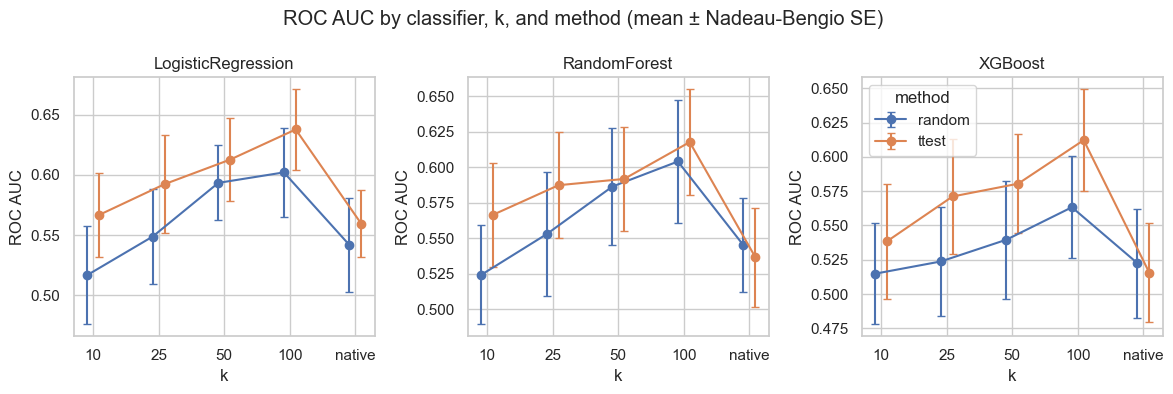

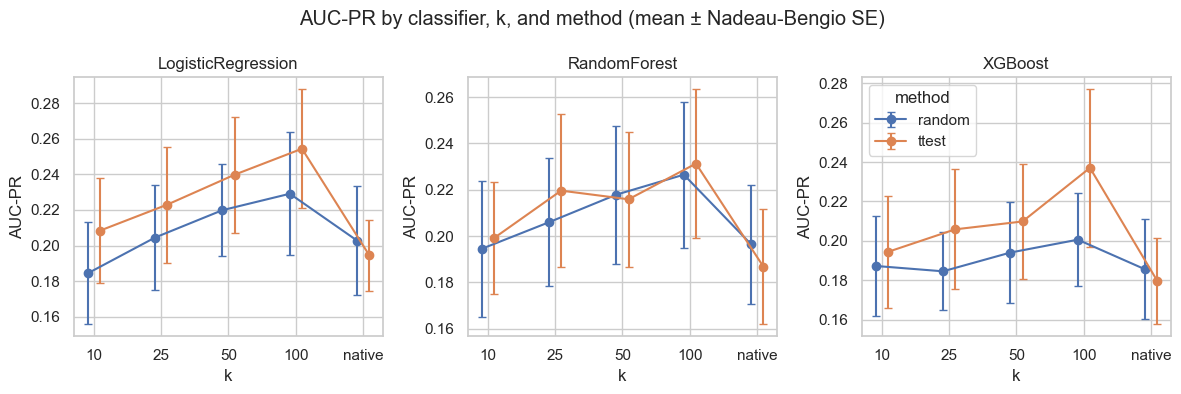

In [13]:
classifiers = sorted(summary["classifier"].unique().tolist())
methods = sorted(summary["method"].unique().tolist())
palette = dict(zip(methods, sns.color_palette(n_colors=len(methods))))

for metric, title in [("auc", "ROC AUC"), ("aupr", "AUC-PR")]:
    mean_col = f"{metric}_mean"
    se_col = f"{metric}_se_nb"

    fig, axes = plt.subplots(
        1, len(classifiers), figsize=(4 * len(classifiers), 4), sharey=False
    )
    if len(classifiers) == 1:
        axes = [axes]

    x_positions = np.arange(len(k_order))
    dodge = 0.18

    for ax, clf in zip(axes, classifiers):
        sub = summary[summary["classifier"] == clf]
        for i, method in enumerate(methods):
            row_lookup = sub[sub["method"] == method].set_index("k")
            y = [row_lookup.loc[k, mean_col] if k in row_lookup.index else np.nan for k in k_order]
            yerr = [row_lookup.loc[k, se_col] if k in row_lookup.index else np.nan for k in k_order]
            offset = (i - (len(methods) - 1) / 2) * dodge
            ax.errorbar(
                x_positions + offset,
                y,
                yerr=yerr,
                fmt="o-",
                color=palette[method],
                label=method,
                capsize=3,
            )
        ax.set_title(clf)
        ax.set_xlabel("k")
        ax.set_ylabel(title)
        ax.set_xticks(x_positions)
        ax.set_xticklabels(k_order)
    axes[-1].legend(title="method", loc="best")
    fig.suptitle(f"{title} by classifier, k, and method (mean ± Nadeau-Bengio SE)")
    fig.tight_layout()
    plt.show()

In [14]:
issues = scores[(scores["auc"].isna()) | (scores["aupr"].isna()) | (scores["n_features_actual"] == 0)].copy()

print(f"Rows with NaN metric or zero features: {len(issues):,} / {len(scores):,}")
if len(issues) > 0:
    issue_summary = (
        issues.groupby(["method", "classifier", "k"], observed=True, as_index=False)
        .agg(n_rows=("split_id", "size"))
        .sort_values("n_rows", ascending=False)
    )
    display(issue_summary)
else:
    print("No issues detected in metrics or feature counts.")

Rows with NaN metric or zero features: 6 / 1,500


,method,classifier,k,n_rows
0,ttest,LogisticRegression,native,2
1,ttest,RandomForest,native,2
2,ttest,XGBoost,native,2


In [15]:
def mean_table_for_k(k_value: str) -> pd.DataFrame:
    subset = scores[scores["k"] == k_value]
    return (
        subset.groupby(["method", "classifier"], observed=True, as_index=False)
        .agg(
            auc_mean=("auc", "mean"),
            aupr_mean=("aupr", "mean"),
            n_features_mean=("n_features_actual", "mean"),
        )
        .sort_values(["classifier", "auc_mean"], ascending=[True, False])
    )

print("Mean performance at k=50")
display(mean_table_for_k("50"))

print("Mean performance at native cutoff")
display(mean_table_for_k("native"))

Mean performance at k=50


,method,classifier,auc_mean,aupr_mean,n_features_mean
3,ttest,LogisticRegression,0.612667,0.239772,50.0
0,random,LogisticRegression,0.593364,0.219885,50.0
4,ttest,RandomForest,0.591773,0.215887,50.0
1,random,RandomForest,0.586394,0.217891,50.0
5,ttest,XGBoost,0.580439,0.209874,50.0
2,random,XGBoost,0.539576,0.194118,50.0


Mean performance at native cutoff


,method,classifier,auc_mean,aupr_mean,n_features_mean
3,ttest,LogisticRegression,0.559438,0.194494,11.4
0,random,LogisticRegression,0.541758,0.202748,20.0
1,random,RandomForest,0.545076,0.196398,20.0
4,ttest,RandomForest,0.536750,0.186836,11.4
2,random,XGBoost,0.522439,0.185570,20.0
5,ttest,XGBoost,0.515578,0.179647,11.4


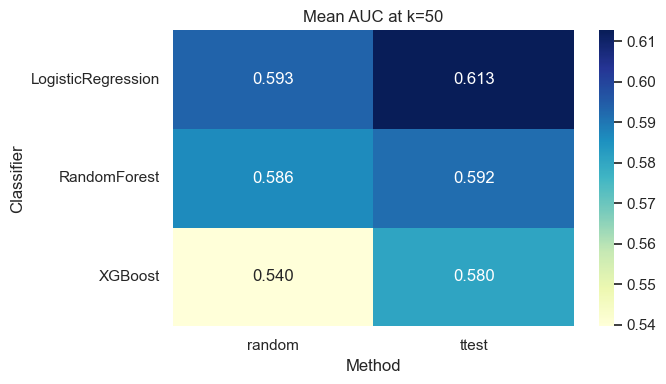

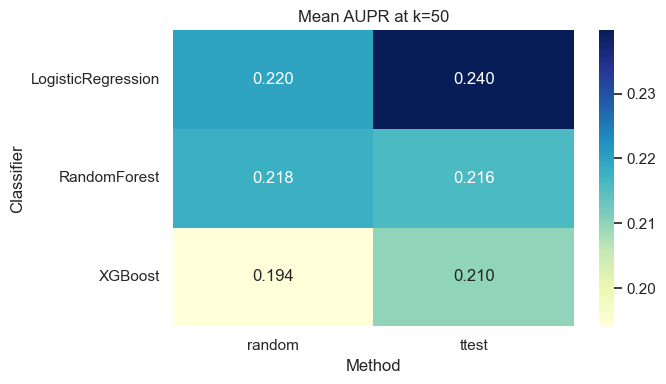

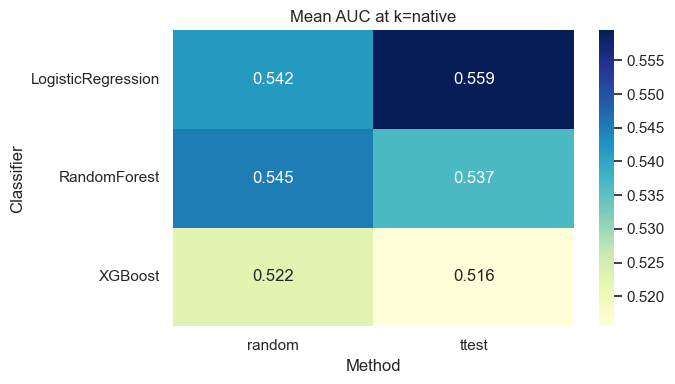

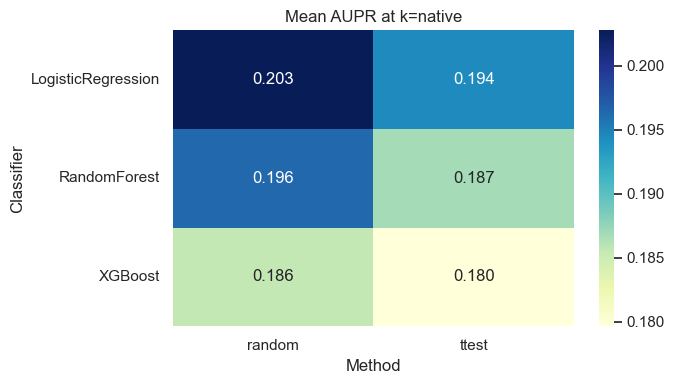

In [16]:
for metric, k_value in [("auc", "50"), ("aupr", "50"), ("auc", "native"), ("aupr", "native")]:
    heat = (
        scores[scores["k"] == k_value]
        .groupby(["classifier", "method"], observed=True)[metric]
        .mean()
        .unstack("method")
    )

    plt.figure(figsize=(7, 4))
    sns.heatmap(heat, annot=True, fmt=".3f", cmap="YlGnBu")
    plt.title(f"Mean {metric.upper()} at k={k_value}")
    plt.xlabel("Method")
    plt.ylabel("Classifier")
    plt.tight_layout()
    plt.show()